### 주성분 분석(PCA)
: 고차원(많은 columns) 데이터를 저차원 데이터를 환원시키는 방법

In [74]:
a=1

In [75]:
import numpy as np

In [76]:
fruits = np.load('data/fruits.npy')
fruits.shape

(300, 100, 100)

In [77]:
# 2차원 배열로 변경하기
fruits_2d = fruits.reshape(-1, 100*100)
fruits_2d.shape

(300, 10000)

#### PCA 모델 구성하기

In [78]:
from sklearn.decomposition import PCA

In [79]:
pca= PCA(n_components=50)
# 300개의 데이터 확실한 Feature의 특징으로 포함한 주성분 50개만 선택

In [80]:
pca.fit(fruits_2d)
# 축소된 차원 크기 확인하기
pca.components_.shape

(50, 10000)

In [81]:
import matplotlib.pyplot as plt

In [82]:
def draw_fruits(arr, ratio=1):
    n = len(arr)              # 샘플의 개수
    row = int(np.ceil(n/10))  # 한 줄에 10개씩 배치할 때 필요한 행의 수 (올림 처리)
    col = n if row < 2 else 10 # 샘플이 10개 미만이면 샘플 개수만큼, 많으면 무조건 10열
    
    fig, axs = plt.subplots(
        row,
        col,         
        figsize = (col*ratio, row*ratio),
        squeeze = False       # 1행이나 1열이어도 항상 2차원 배열로 axs를 다루기 위함
    )
    
    for i in range(row):
        for j in range(col):
            if i*10+j < n:    # 전체 샘플 개수를 넘지 않을 때만 그리기
                axs[i,j].imshow(arr[i*10+j], cmap='gray')
            axs[i,j].axis('off') # 이미지가 없는 빈 칸도 테두리를 지워 깔끔하게 처리
            
    plt.show()

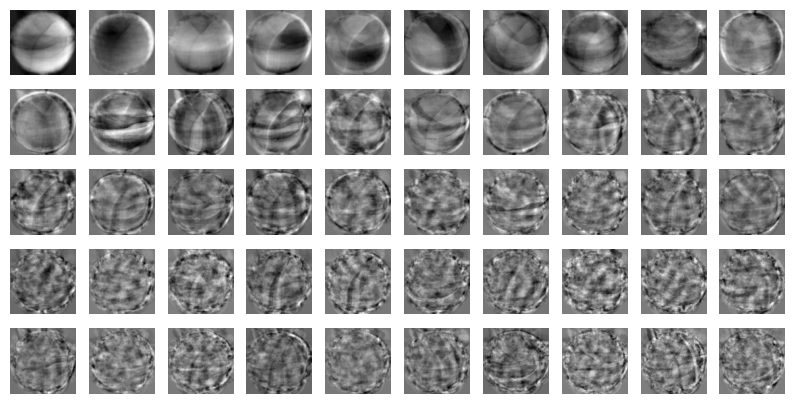

In [83]:
# 3차원 배열로 변경하기
draw_fruits(pca.components_.reshape(-1, 100, 100))

In [84]:
# 행의 갯수는 원본가 동일하게 하고, Feature의 특성을 50개의 주성분으로 변경
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape) # 10000 > 50 열의 갯수를 줄임

(300, 50)


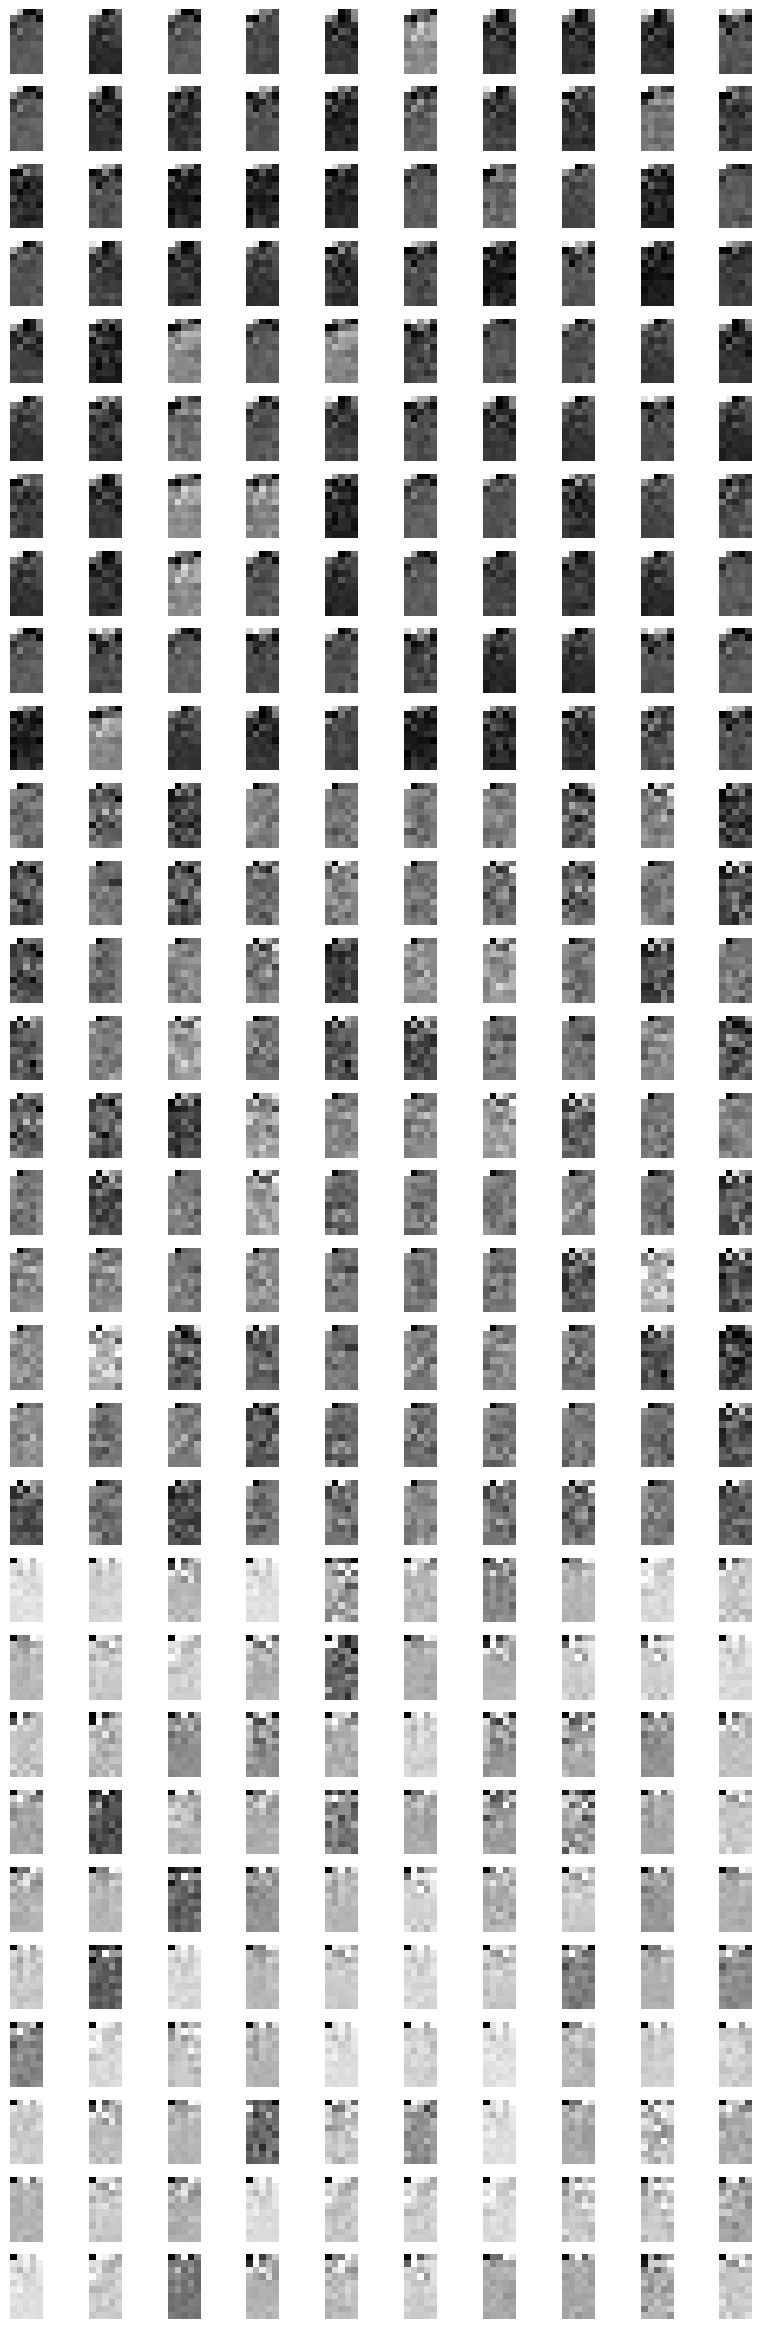

In [85]:
draw_fruits(fruits_pca.reshape(-1, 10, 5))

#### 원본 데이터 재구성

In [86]:
fruits_inverse = pca.inverse_transform(fruits_pca)
fruits_inverse.shape

(300, 10000)

In [87]:
# 그림을 그리기 위해 2차원으로 확장
fruits_reconstruct = fruits_inverse.reshape(-1, 100, 100)

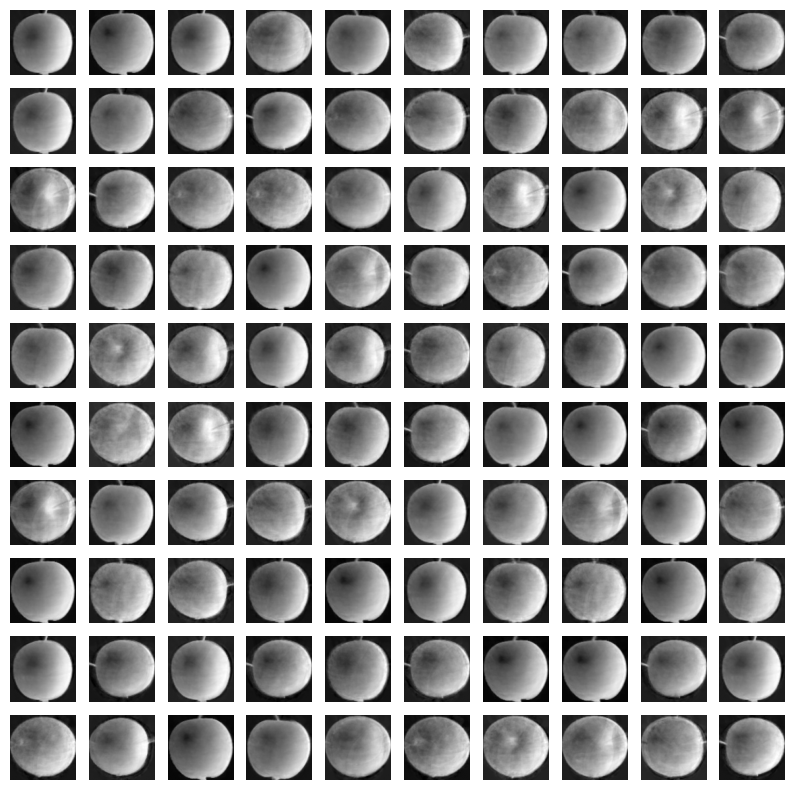

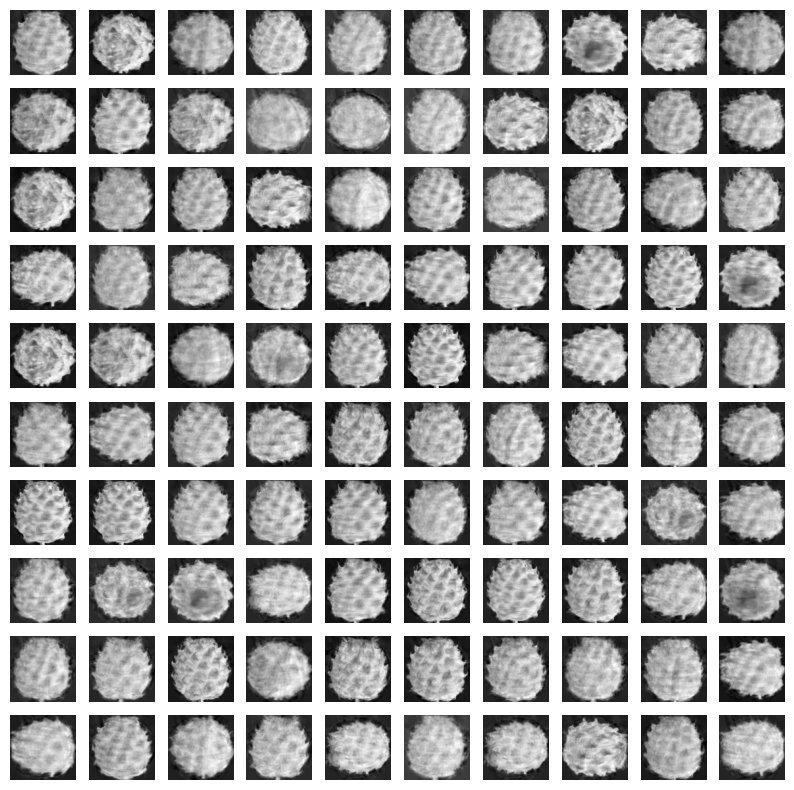

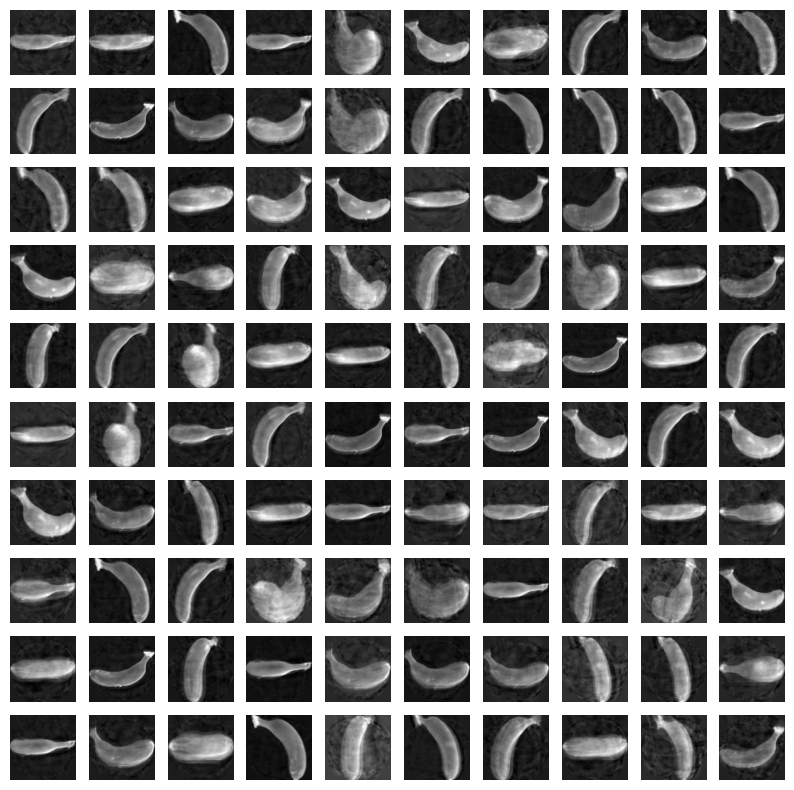

In [88]:
for start in [0, 100, 200]:
    draw_fruits(fruits_reconstruct[start:start+100])
    print('\n')

1/200의 데이터 특성만 가지고도 원본과 비슷하게 배경은 깨끗하지 않으나 물체의 구성이 가능하다

#### 설명된 분산
: 주성분으로 구성할 때 원본 데이터의 분산을 어느 정도 유지하고 있는지 확인하는 방법

In [89]:
np.sum(pca.explained_variance_ratio_)
# 50개의 주성분이 전체 데이터의 92%까지 복원 가능하기

np.float64(0.9223083429822372)

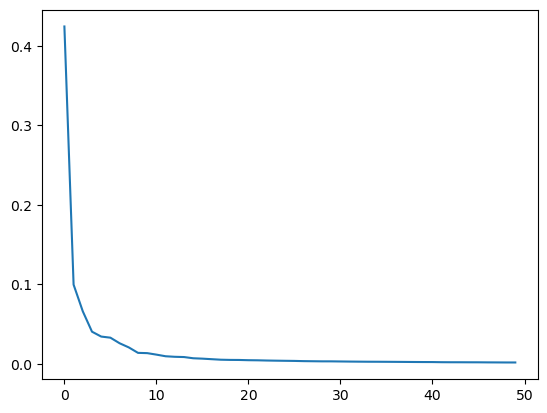

In [90]:
# 그래프 그리기
plt.plot(pca.explained_variance_ratio_)
plt.show()

In [91]:
#### 주성분 10개만 선정하기
pca= PCA(n_components=10)
pca10 = pca.fit(fruits_2d)

In [92]:
pca10.components_.shape

(10, 10000)

In [93]:
fruits_pca10 = pca10.transform(fruits_2d)
fruits_pca10.shape # 300은 원본의 300이 아니라 주성분 10개로 만들어진 300

(300, 10)

In [94]:
fruits_inverse10 = pca10.inverse_transform(fruits_pca10)
fruits_inverse10.shape

(300, 10000)

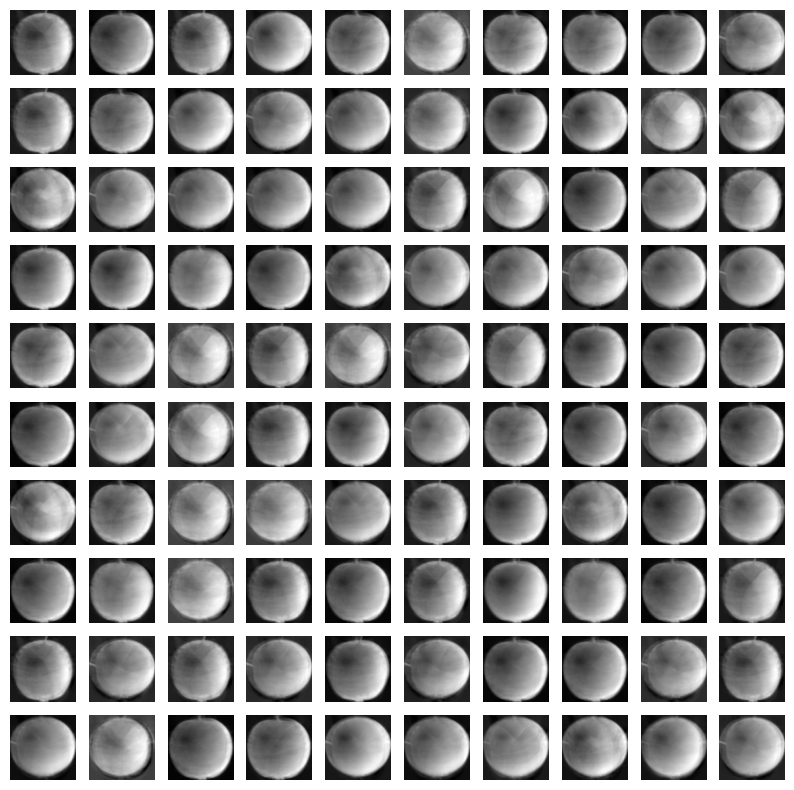

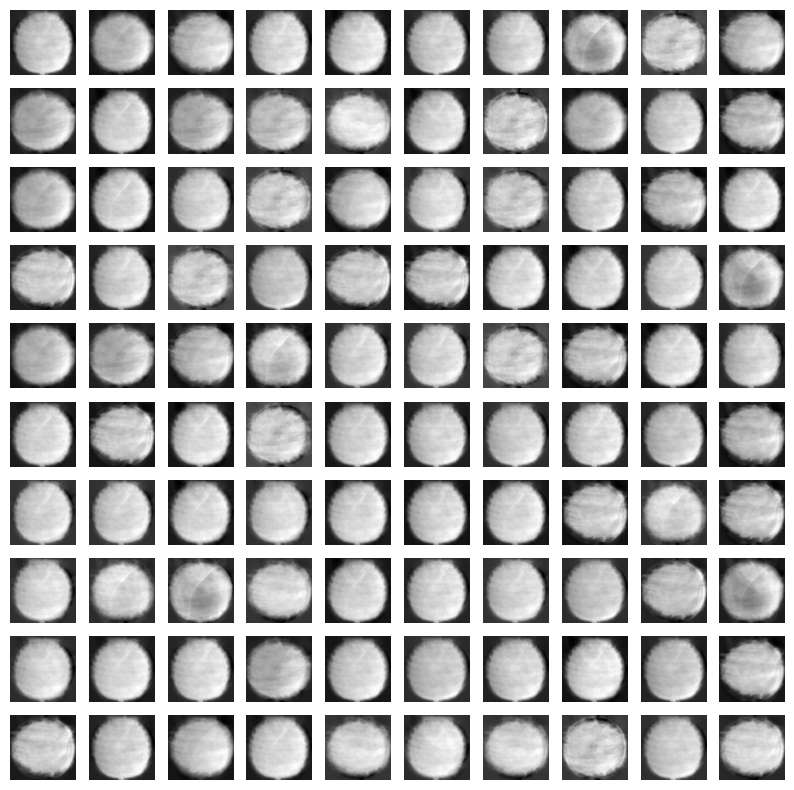

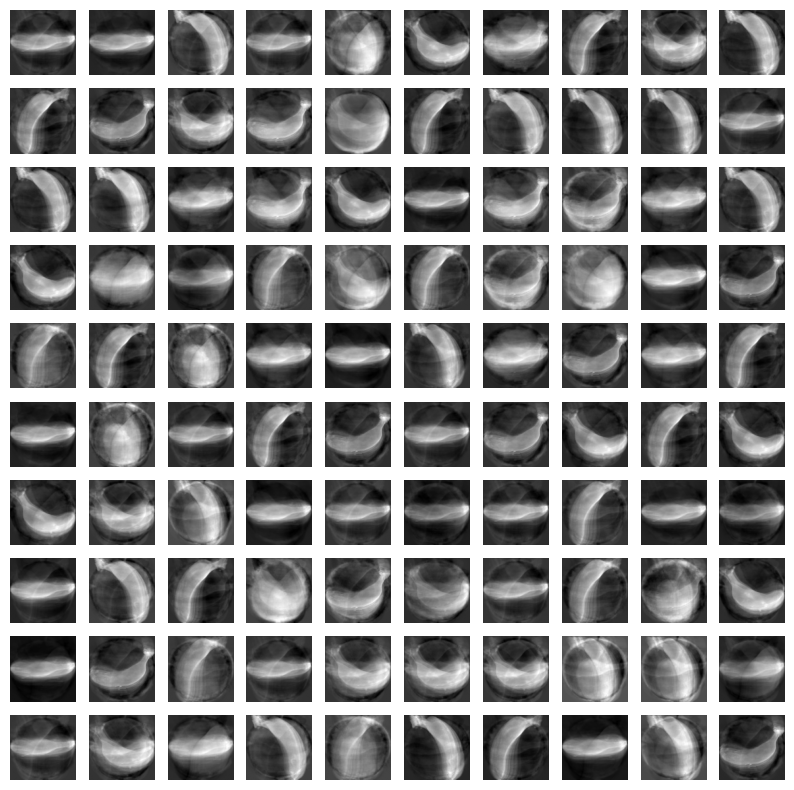

In [95]:
for start in [0, 100, 200]:
    draw_fruits(fruits_inverse10.reshape(-1, 100, 100)[start:start+100])
    print('\n')

In [96]:
np.sum(pca.explained_variance_ratio_)

np.float64(0.7711096018208616)

In [97]:
# 주성분을 30으로 맞추기
pca= PCA(n_components=30)
pca30 = pca.fit(fruits_2d)

In [98]:
fruits_pca30 = pca30.transform(fruits_2d)
fruits_pca30.shape

(300, 30)

In [99]:
fruits_inverse30 = pca30.inverse_transform(fruits_pca30)
fruits_inverse30.shape

(300, 10000)

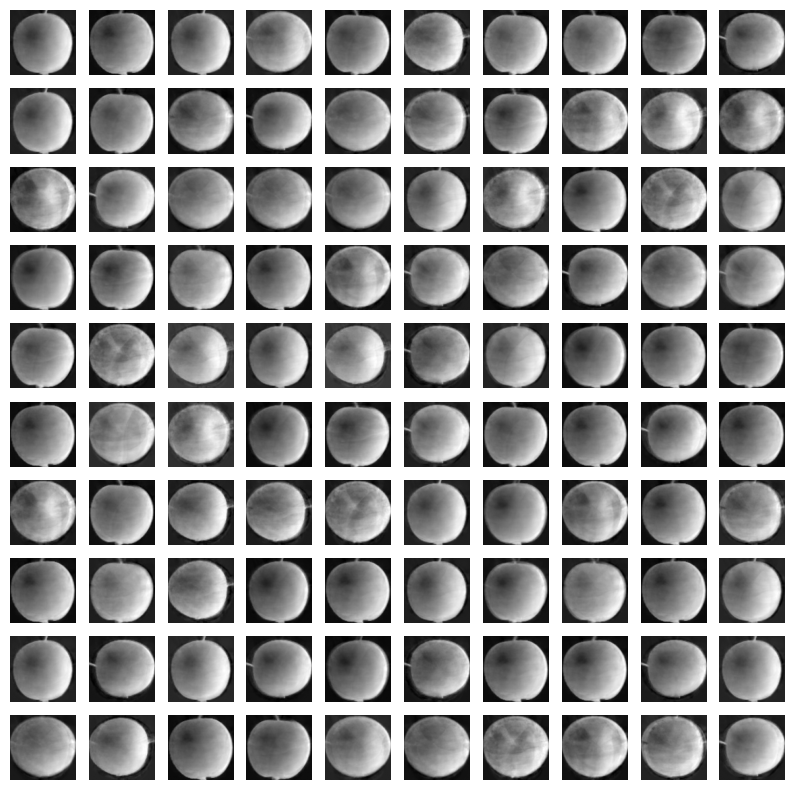

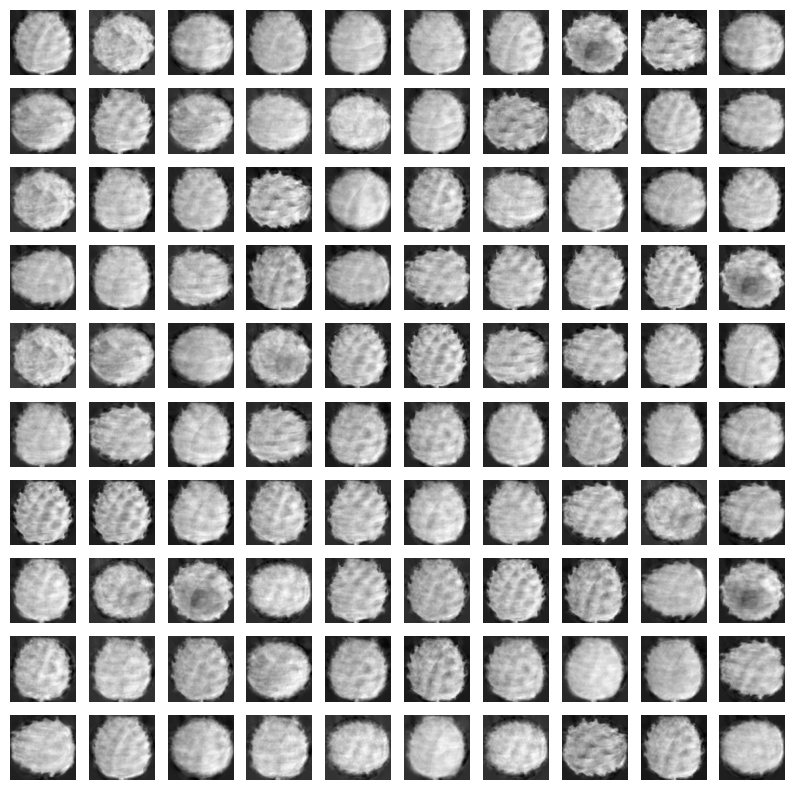

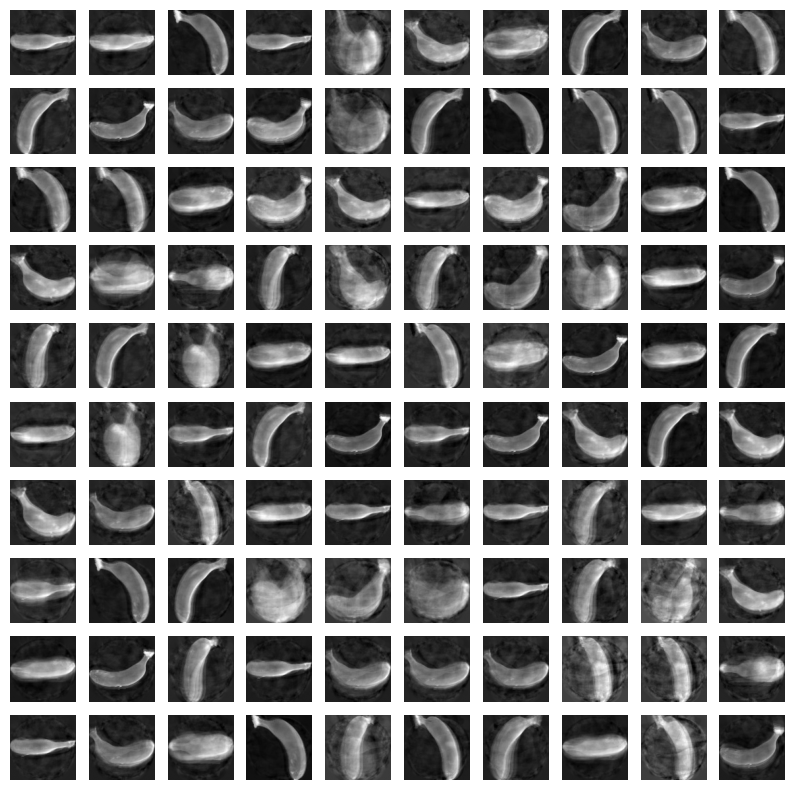

In [100]:
for start in [0, 100, 200]:
    draw_fruits(fruits_inverse30.reshape(-1, 100, 100)[start:start+100])
    print('\n')

In [101]:
np.sum(pca.explained_variance_ratio_)

np.float64(0.8792534356335147)

#### 로지스틱 회귀분석에 주성분 분석을 대입하여 사용해보기

In [110]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [105]:
np.ones(10)*2

array([2., 2., 2., 2., 2., 2., 2., 2., 2., 2.])

In [106]:
[0]*10

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [118]:
target = np.array([
    [0]*100, 
    [1]*100,
    [2]*100
])
target = target.reshape(-1)
print(target.shape)
fruits_2d.shape

(300,)


(300, 10000)

In [119]:
from sklearn.model_selection import cross_val_score , cross_validate

In [121]:
scores = cross_validate(lr, fruits_2d, target)
scores

{'fit_time': array([0.11647987, 0.08402824, 0.08823204, 0.09887099, 0.11024308]),
 'score_time': array([0.00142193, 0.0012989 , 0.00128293, 0.000736  , 0.00187182]),
 'test_score': array([1.        , 1.        , 1.        , 0.98333333, 1.        ])}

In [124]:
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
0.009503030776977539


#### 주성분 분석의 분산 크기를 정해 사용하기

In [136]:
pca = PCA(n_components = 0.5)
pca.fit(fruits_2d)

,n_components,0.5
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [137]:
fruits_pca = pca.transform(fruits_2d)

In [138]:
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
0.011251735687255859


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [139]:
from sklearn.cluster import KMeans

In [140]:
km = KMeans()
km.fit(fruits_pca)

,n_clusters,8
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [142]:
np.unique(km.labels_, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32),
 array([32, 40, 69, 18, 41, 19, 22, 59]))

- 현재 PCA는 2개이다.
- 뚜렷한 분포가 확인 가능하다
- 즉 차원이 큰 데이터의 분포를 그래프로 확인할 경우에는 주성분 분석을 활용한다.

In [145]:
1920 * 1080

2073600